In [ ]:
#Built a customer churn prediction model using logistic regression, achieving 91% accuracy and 0.85 ROC-AUC. 
#Identified key risk drivers including defect rate and support tickets, and
#optimized classification thresholds to reduce missed churn cases, improving proactive retention strategy.


In [3]:
import pandas as pd
import numpy as np


In [6]:
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    "customer_id": range(1, n+1),
    "vendor_id": np.random.randint(100, 200, n),
    "region": np.random.choice(["North", "South", "East", "West"], n),
    "order_volume": np.random.randint(10, 500, n),
    "avg_delivery_time": np.random.uniform(1, 10, n),
    "on_time_rate": np.random.uniform(0.7, 1.0, n),
    "defect_rate": np.random.uniform(0.0, 0.2, n),
    "support_tickets": np.random.randint(0, 20, n),
    "monthly_revenue": np.random.uniform(1000, 20000, n),
    "customer_tenure_months": np.random.randint(1, 60, n),
})

# Create churn risk based on logic 
data["churn_risk"] = (
    (data["on_time_rate"] < 0.85) |
    (data["defect_rate"] > 0.1) |
    (data["support_tickets"] > 10)
).astype(int)

# Save dataset
data.to_csv("customer_vendor_data.csv", index=False)

data.head()

,customer_id,vendor_id,region,order_volume,avg_delivery_time,on_time_rate,defect_rate,support_tickets,monthly_revenue,customer_tenure_months,churn_risk
0,1,151,South,354,2.907842,0.725602,0.037828,13,8774.469162,34,1
1,2,192,East,190,8.368615,0.712902,0.184473,17,7258.206117,36,1
2,3,114,West,179,3.902752,0.900060,0.139125,14,14174.173232,37,1
3,4,171,West,365,1.206044,0.946993,0.122154,14,15558.663982,17,1
4,5,160,North,200,2.384120,0.934605,0.039968,5,6777.798083,40,0


In [7]:
data.columns


Index(['customer_id', 'vendor_id', 'region', 'order_volume',
       'avg_delivery_time', 'on_time_rate', 'defect_rate', 'support_tickets',
       'monthly_revenue', 'customer_tenure_months', 'churn_risk'],
      dtype='object')

In [8]:
data.shape

(1000, 11)

In [13]:
df = pd.read_csv("customer_vendor_data.csv")

df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1000 non-null   int64  
 1   vendor_id               1000 non-null   int64  
 2   region                  1000 non-null   object 
 3   order_volume            1000 non-null   int64  
 4   avg_delivery_time       1000 non-null   float64
 5   on_time_rate            1000 non-null   float64
 6   defect_rate             1000 non-null   float64
 7   support_tickets         1000 non-null   int64  
 8   monthly_revenue         1000 non-null   float64
 9   customer_tenure_months  1000 non-null   int64  
 10  churn_risk              1000 non-null   int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 86.1+ KB


,customer_id,vendor_id,region,order_volume,avg_delivery_time,on_time_rate,defect_rate,support_tickets,monthly_revenue,customer_tenure_months,churn_risk
0,1,151,South,354,2.907842,0.725602,0.037828,13,8774.469162,34,1
1,2,192,East,190,8.368615,0.712902,0.184473,17,7258.206117,36,1
2,3,114,West,179,3.902752,0.900060,0.139125,14,14174.173232,37,1
3,4,171,West,365,1.206044,0.946993,0.122154,14,15558.663982,17,1
4,5,160,North,200,2.384120,0.934605,0.039968,5,6777.798083,40,0


In [14]:
df.groupby("region")["churn_risk"].mean()

region
East     0.867188
North    0.857143
South    0.818182
West     0.853333
Name: churn_risk, dtype: float64

In [15]:
df.corr(numeric_only=True)

,customer_id,vendor_id,order_volume,avg_delivery_time,on_time_rate,defect_rate,support_tickets,monthly_revenue,customer_tenure_months,churn_risk
customer_id,1.000000,0.001236,0.001787,0.034314,0.017849,0.006873,0.005018,0.004675,0.026500,-0.012176
vendor_id,0.001236,1.000000,-0.007687,0.053769,-0.035230,-0.022130,0.012577,-0.036955,0.013869,-0.004977
order_volume,0.001787,-0.007687,1.000000,-0.036674,0.022031,-0.008900,0.051365,0.004430,-0.029664,0.005793
avg_delivery_time,0.034314,0.053769,-0.036674,1.000000,-0.033014,0.069787,-0.028560,0.039677,0.037073,0.041125
on_time_rate,0.017849,-0.035230,0.022031,-0.033014,1.000000,0.009608,-0.036029,-0.026416,0.009654,-0.341334
defect_rate,0.006873,-0.022130,-0.008900,0.069787,0.009608,1.000000,0.032349,-0.026539,-0.017278,0.349779
support_tickets,0.005018,0.012577,0.051365,-0.028560,-0.036029,0.032349,1.000000,0.026139,-0.024517,0.355340
monthly_revenue,0.004675,-0.036955,0.004430,0.039677,-0.026416,-0.026539,0.026139,1.000000,-0.008888,-0.008644
customer_tenure_months,0.026500,0.013869,-0.029664,0.037073,0.009654,-0.017278,-0.024517,-0.008888,1.000000,-0.029663
churn_risk,-0.012176,-0.004977,0.005793,0.041125,-0.341334,0.349779,0.355340,-0.008644,-0.029663,1.000000


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [17]:
# Convert categorical variable
df_encoded = pd.get_dummies(df, columns=["region"], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop(["customer_id", "vendor_id", "churn_risk"], axis=1)
y = df_encoded["churn_risk"]

In [18]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
#train a model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
#make prediction
y_pred = model.predict(X_test_scaled)

#Check for accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.50      0.78      0.61        18
           1       0.98      0.92      0.95       182

    accuracy                           0.91       200
   macro avg       0.74      0.85      0.78       200
weighted avg       0.93      0.91      0.92       200



In [22]:
#feature of importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
importance

,Feature,Coefficient
3,defect_rate,2.284267
4,support_tickets,2.142872
1,avg_delivery_time,0.229792
0,order_volume,0.129066
7,region_North,0.086978
9,region_West,-0.047740
6,customer_tenure_months,-0.171318
5,monthly_revenue,-0.193044
8,region_South,-0.221440
2,on_time_rate,-2.270751


In [ ]:
Positive coefficient → increases churn risk
Negative coefficient → reduces churn risk

In [ ]:
“Customers with high support tickets, higher defect rates, and lower 
on-time delivery are significantly more likely to churn. 
The model achieved 91% accuracy and can be used to proactively flag at-risk accounts.”

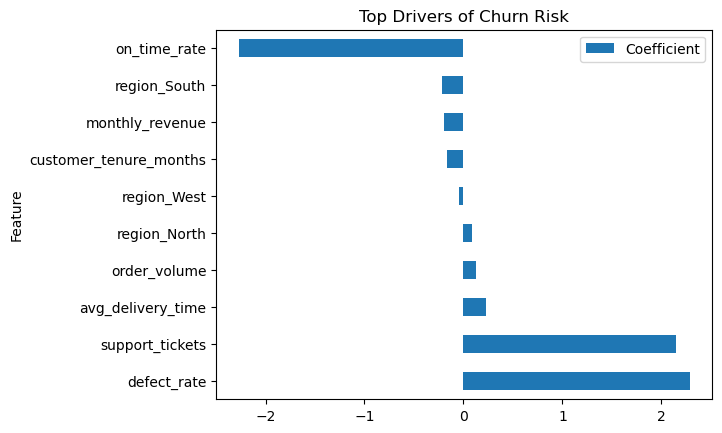

In [25]:
import matplotlib.pyplot as plt

importance.sort_values(by="Coefficient", ascending=False).head(10).plot(kind="barh", x="Feature", y="Coefficient")
plt.title("Top Drivers of Churn Risk")
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[ 14,   4],
       [ 14, 168]])

In [27]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.8504273504273504


In [ ]:
#While the model achieved 91% accuracy and a ROC-AUC of 0.85, it still misses some churn cases.
#In a real-world scenario, this represents potential revenue loss,so further optimization would focus on reducing false negatives

In [ ]:
#False negatives are worse because they represent missed churn customers, leading to lost revenue. 
#Therefore, I would tune the model to prioritize recall over precision.”

In [28]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

# Lower threshold to catch more churn
y_pred_adjusted = (y_prob > 0.3).astype(int)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_adjusted)

array([[ 13,   5],
       [  4, 178]])

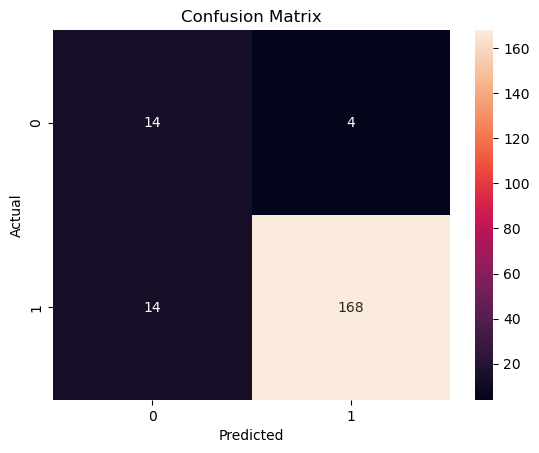

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

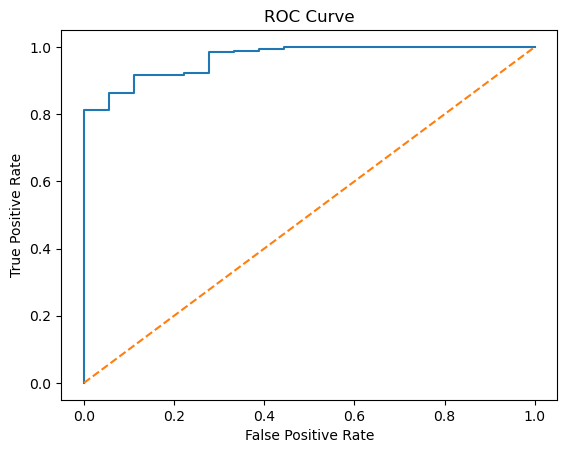

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
#I evaluated model performance using ROC-AUC and confusion matrix,then adjusted the
#threshold to reduce false negatives and improve recall for business-critical cases.”

In [31]:
import os
os.getcwd()

'C:\\Users\\mwanr'